# 2.5 自动微分 (Automatic Differentiation)

正如 2.4 节中所说，求导是几乎所有深度学习优化算法的关键步骤。
深度学习框架通过自动计算导数，即**自动微分（automatic differentiation）**来加快求导。
实际中，根据设计好的模型，系统会构建一个**计算图（computational graph）**，来跟踪计算是哪些数据通过哪些操作组合起来产生输出。
自动微分使系统能够随后**反向传播（backpropagate）**梯度。这里，反向传播意味着跟踪整个计算图，填充关于每个参数的偏导数。

## 2.5.1 一个简单的例子
作为一个演示例子，假设我们想对函数 $y = 2\mathbf{x}^\top \mathbf{x}$ 关于列向量 $\mathbf{x}$ 求导。首先，我们创建变量 $\mathbf{x}$ 并为其分配一个初始值。

In [1]:
# 【所属小节】2.5.1 一个简单的例子
# 【作用说明】创建初始自变量向量 x
import torch

x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

在我们计算 $y$ 关于 $\mathbf{x}$ 的梯度之前，需要一个地方来存储梯度。
重要的是，我们不会在每次对一个参数求导时都分配新的内存。因为我们经常会成千上万次地更新相同的参数，每次都分配新的内存可能很快就会将内存耗尽。
注意，一个标量函数关于向量 $\mathbf{x}$ 的梯度是向量，并且与 $\mathbf{x}$ 具有相同的形状。

In [2]:
# 【所属小节】2.5.1 一个简单的例子
# 【作用说明】设置 requires_grad=True 开启梯度追踪并查看初始梯度
x.requires_grad_(True)  # 等价于 x = torch.arange(4.0, requires_grad=True)
x.grad  # 默认值是 None

现在计算 $y$。

In [3]:
# 【所属小节】2.5.1 一个简单的例子
# 【作用说明】计算目标标量函数 y = 2 * x^T * x
y = 2 * torch.dot(x, x)
y

tensor(28., grad_fn=<MulBackward0>)

$\mathbf{x}$ 是一个长度为 4 的向量，计算 $\mathbf{x}$ 和 $\mathbf{x}$ 的点积，得到了我们赋值给 $y$ 的标量输出。
接下来，通过调用反向传播函数来自动计算 $y$ 关于 $\mathbf{x}$ 每个分量的梯度，并打印这些梯度。

In [4]:
# 【所属小节】2.5.1 一个简单的例子
# 【作用说明】执行反向传播计算梯度并查看 x.grad
y.backward()
x.grad

tensor([ 0.,  4.,  8., 12.])

函数 $y = 2\mathbf{x}^\top \mathbf{x}$ 关于 $\mathbf{x}$ 的梯度应为 $4\mathbf{x}$。让我们快速验证这个梯度是否计算正确。

In [5]:
# 【所属小节】2.5.1 一个简单的例子
# 【作用说明】验证自动微分计算的梯度是否与理论数学导数 4*x 完全一致
x.grad == 4 * x

tensor([True, True, True, True])

现在计算 $\mathbf{x}$ 的另一个函数。

In [6]:
# 【所属小节】2.5.1 一个简单的例子
# 【作用说明】清除累计梯度并求新函数 y = x.sum() 的梯度
# 在默认情况下，PyTorch会累积梯度，我们需要清除之前的值
x.grad.zero_()
y = x.sum()
y.backward()
x.grad

tensor([1., 1., 1., 1.])

## 2.5.2 非标量变量的反向传播
当 $y$ 不是标量时，向量 $y$ 关于向量 $\mathbf{x}$ 的导数的最自然解释是一个矩阵。
对于高阶和高维的 $y$ 和 $\mathbf{x}$，求导的结果可以是一个高阶张量。
然而，虽然这些更奇特的对象确实出现在高级机器学习中（包括深度学习中），但当调用向量的反向计算时，我们通常会试图计算一批训练样本中每个组成部分的损失函数的导数。
这里，我们的目的不是计算微分矩阵，而是单独计算批量中每个样本的偏导数之和。

In [7]:
# 【所属小节】2.5.2 非标量变量的反向传播
# 【作用说明】对非标量向量进行反向传播求偏导数的和
# 对非标量调用backward需要传入一个gradient参数，该参数指定微分函数关于self的梯度。
# 本例只想求偏导数的和，所以传递一个1的梯度是合适的
x.grad.zero_()
y = x * x
# 等价于 y.backward(torch.ones(len(x)))
y.sum().backward()
x.grad

tensor([0., 2., 4., 6.])

## 2.5.3 分离计算
有时，我们希望将某些计算移动到记录的计算图之外。
例如，假设 $y$ 是作为 $\mathbf{x}$ 的函数计算的，而 $z$ 则是作为 $y$ 和 $\mathbf{x}$ 的函数计算的。
想象一下，我们想计算 $z$ 关于 $\mathbf{x}$ 的梯度，但由于某种原因，希望将 $y$ 视为一个常数，并且只考虑到 $\mathbf{x}$ 在 $y$ 被计算后发挥的作用。
这里可以分离 $y$ 来返回一个新变量 $u$，该变量与 $y$ 具有相同的值，但丢弃计算图中如何计算 $y$ 的任何信息。
换句话说，梯度不会向后流经 $u$ 到 $\mathbf{x}$。
因此，下面的反向传播函数计算 $z = u \times x$ 关于 $\mathbf{x}$ 的偏导数，同时将 $u$ 作为常数处理，而不是 $z = x \times x \times x$ 关于 $\mathbf{x}$ 的偏导数。

In [8]:
# 【所属小节】2.5.3 分离计算
# 【作用说明】使用 detach() 截断梯度流，将 u 当作常数求导
x.grad.zero_()
y = x * x
u = y.detach()
z = u * x
z.sum().backward()
x.grad == u

tensor([True, True, True, True])

由于记录了 $y$ 的计算结果，我们可以随后在 $y$ 上调用反向传播，得到 $y = x \times x$ 关于 $\mathbf{x}$ 的导数，即 $2\mathbf{x}$。

In [9]:
# 【所属小节】2.5.3 分离计算
# 【作用说明】在原始 y 上反向传播，求完整的 y = x*x 导数 (2*x)
x.grad.zero_()
y.sum().backward()
x.grad == 2 * x

tensor([True, True, True, True])

## 2.5.4 Python控制流的梯度计算
使用自动微分的一个好处是：即使构建函数的计算图需要通过 Python 控制流（例如，条件、循环或任意函数调用），我们仍然可以计算得到的变量的梯度。
在下面的代码中，while 循环的迭代次数和 if 语句的结果都取决于输入 $a$ 的值。

In [10]:
# 【所属小节】2.5.4 Python控制流的梯度计算
# 【作用说明】定义带有 while 循环与 if-else 条件分支的分段线性函数 f(a)
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

让我们计算梯度。

In [11]:
# 【所属小节】2.5.4 Python控制流的梯度计算
# 【作用说明】创建标量输入 a 并对其反向传播求导
a = torch.randn(size=(), requires_grad=True)
d = f(a)
d.backward()

我们现在可以分析上面定义的 $f$ 函数。
请注意，它在其输入 $a$ 中是分段线性的。换言之，对于任何 $a$，存在某个常量标量 $k$，使得 $f(a) = k \times a$，其中 $k$ 的值取决于输入 $a$，因此可以用 $d / a$ 验证梯度是否正确。

In [12]:
# 【所属小节】2.5.4 Python控制流的梯度计算
# 【作用说明】验证分段线性控制流的导数是否恒等于 d / a
a.grad == d / a

tensor(True)

---
## 2.5 课后练习题代码实验与验证
本部分包含原书第 91 页课后练习题 1 ~ 5 题的实操代码与分析验证。

### 练习 2：连续运行两次反向传播函数
测试直接运行两次 `backward()` 的报错现象，以及如何使用 `retain_graph=True` 正常运行。

In [13]:
# ==============================================================================
# 【练习 2】连续调用两次 backward() 报错测试与 retain_graph=True 解决方案
# ==============================================================================
x = torch.tensor(3.0, requires_grad=True)
y = x * x
y.backward(retain_graph=True)  # 显式保留计算图
print("第一次求导后 x.grad:", x.grad)  # 2*x = 6

y.backward()  # 第二次成功执行，并且梯度会累加！
print("第二次求导后 x.grad (累加 6+6):", x.grad)  # 12
# ------------------------------------------------------------------------------
# 【原因】PyTorch 默认在第一次 backward() 后自动释放计算图以节省内存。
# 若不加 retain_graph=True，第二次调用会抛出 RuntimeError。
# ==============================================================================

第一次求导后 x.grad: tensor(6.)
第二次求导后 x.grad (累加 6+6): tensor(12.)


### 练习 3：控制流例子中将变量 $a$ 更改为随机矩阵
观察将标量改为 $(3, 4)$ 矩阵时，控制流能否正常执行，以及反向传播的改变。

In [14]:
# ==============================================================================
# 【练习 3】控制流函数输入矩阵 a 时的求导处理
# ==============================================================================
a = torch.randn(size=(3, 4), requires_grad=True)
d = f(a)  # 前向控制流正常执行

# 此时 d 是非标量矩阵，直接 d.backward() 会报 RuntimeError
# 必须对其求和转为标量：
d.sum().backward()

print("a.grad 形状:", a.grad.shape)
print("验证 a.grad 与 d/a 是否一致:", torch.allclose(a.grad, d / a))
# ==============================================================================

a.grad 形状: torch.Size([3, 4])
验证 a.grad 与 d/a 是否一致: True


### 练习 4：重新设计一个求控制流梯度的例子并分析

In [15]:
# ==============================================================================
# 【练习 4】自定义分段控制流函数的梯度验证
# ==============================================================================
def custom_control_flow(a):
    if a > 0:
        b = a ** 3
    else:
        b = -2 * a
    while b < 100:
        b = b * 3
    return b

a = torch.tensor(2.0, requires_grad=True)
d = custom_control_flow(a)
d.backward()

# 解析分析：a=2.0 > 0 -> b=a^3=8，循环乘以3三次至216停止 -> d = 27*a^3
# 理论导数 dd/da = 81*a^2 = 81*4 = 324.0
print("自动求导计算结果 a.grad:", a.grad.item())
print("手算理论导数结果:", 81 * (2.0 ** 2))
assert a.grad.item() == 324.0
# ==============================================================================

自动求导计算结果 a.grad: 324.0
手算理论导数结果: 324.0


### 练习 5：绘制 $f(x) = \sin(x)$ 及其导数（不使用 $\cos(x)$，完全基于自动求导）

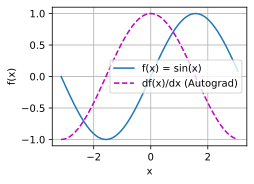

In [16]:
# ==============================================================================
# 【练习 5】基于纯自动求导绘制正弦函数与导函数曲线
# ==============================================================================
from d2l import torch as d2l

# 1. 生成连续区间 x 并开启求导追踪
x = torch.arange(-torch.pi, torch.pi, 0.1, requires_grad=True)
y = torch.sin(x)

# 2. 非标量反向传播求导
y.sum().backward()

# 3. 使用 d2l.plot 绘制曲线，不使用 cos(x)，直接使用 x.grad
d2l.plot(x.detach(), [y.detach(), x.grad], 'x', 'f(x)', 
         legend=['f(x) = sin(x)', 'df(x)/dx (Autograd)'])
# ==============================================================================